# Komplettlauf: die verkettete End-to-End-Pipeline

Dieses Notebook wertet den **Full Run** aus – die zusammenhängende \ac{ETL}-Strecke,
bei der jedes Modell alle neun Schritte nacheinander durchläuft und die Ausgabe eines
Schritts die Eingabe des nächsten ist (`scripts/run_pipeline.py`).

Der Unterschied zu den drei Kategorie-Notebooks ist entscheidend: Dort bekommt **jede
Aufgabe die rohen, dreckigen Daten** und wird unabhängig bewertet. Hier arbeitet jeder
Schritt auf dem Ergebnis seiner Vorgänger. Damit werden zwei Effekte messbar, die die
unabhängigen Läufe nicht zeigen können:

- **Vorbereitung:** Spätere Schritte profitieren von bereits normalisierten Daten
  (die Schlüssel-Deduplizierung kann nach ISO-Datumsformat sauber sortieren).
- **Fehlerfortpflanzung und Kaskaden-Abbruch:** Eine kleine Abweichung in einem frühen
  Schritt pflanzt sich fort; ein Absturz blockiert alle abhängigen Folgeschritte.

Kennzahl ist wie überall die **abgeglichene Genauigkeit**, gemessen gegen eine
*verkettete Referenz*: dieselbe Schrittfolge, ausgeführt mit den regelbasierten
Referenzfunktionen. Je Schritt sind bis zu drei Versuche erlaubt (Retry nach Absturz
oder unvollständigem Schema).

In [1]:
%matplotlib inline
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reporting import pipeline_analysis as pa
from reporting import compare
from reporting.analysis import PROVIDER_LABEL, load_runs
from experiments.pipeline_runner import PIPELINE

seed = 1
pipe = pa.load_pipeline(seed)
PROVS = [p for p in compare.MODEL_ORDER if p in set(pipe.provider)]
LABELS = [PROVIDER_LABEL[p] for p in PROVS]
STEPS = [s.name for s in PIPELINE]
STEP_LABELS = [s.label for s in PIPELINE]

print(f"Seed {seed}: {len(PROVS)} Modelle x {len(STEPS)} Schritte = {len(pipe)} Schritt-Laeufe")
print(f"Grafiken werden gespeichert unter: {compare.FIG_DIR}")
pipe.head()

Seed 1: 4 Modelle x 9 Schritte = 36 Schritt-Laeufe
Grafiken werden gespeichert unter: C:\Users\geige\Desktop\DHBW\Bachelorarbeit\project\figures


,provider,label,step,step_label,order,status,accuracy,attempts,error,cost_usd,prompt_tokens,completion_tokens,row_actual,row_expected,model
0,anthropic,Claude,cleaning_easy,1 · Bereinigung: Leerzeichen & fehlende Werte,0,ok,1.000000,1,NaN,0.005970,450,308,540.0,540.0,claude-sonnet-5
1,anthropic,Claude,cleaning_medium,2 · Bereinigung: Datumsformate,1,ok,1.000000,1,NaN,0.017931,502,1095,540.0,540.0,claude-sonnet-5
2,anthropic,Claude,cleaning_hard,3 · Bereinigung: Ländercodes (ISO),2,ok,0.941481,1,NaN,0.032640,485,2079,540.0,540.0,claude-sonnet-5
3,anthropic,Claude,dedup_easy,4 · Deduplizierung: exakte Duplikate,3,ok,0.927404,1,NaN,0.004776,437,231,520.0,520.0,claude-sonnet-5
4,anthropic,Claude,dedup_medium,5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),4,ok,0.927043,1,NaN,0.004740,475,221,514.0,514.0,claude-sonnet-5


## 1 · Verlauf der Pipeline auf einen Blick

Zeilen = Schritte (von oben nach unten der Datenfluss), Spalten = Modelle. Grüne Felder
zeigen die Genauigkeit des Schritts, rote den Abbruch, graue die dadurch blockierten
Folgeschritte (`figures/pipeline_verlauf.png`).

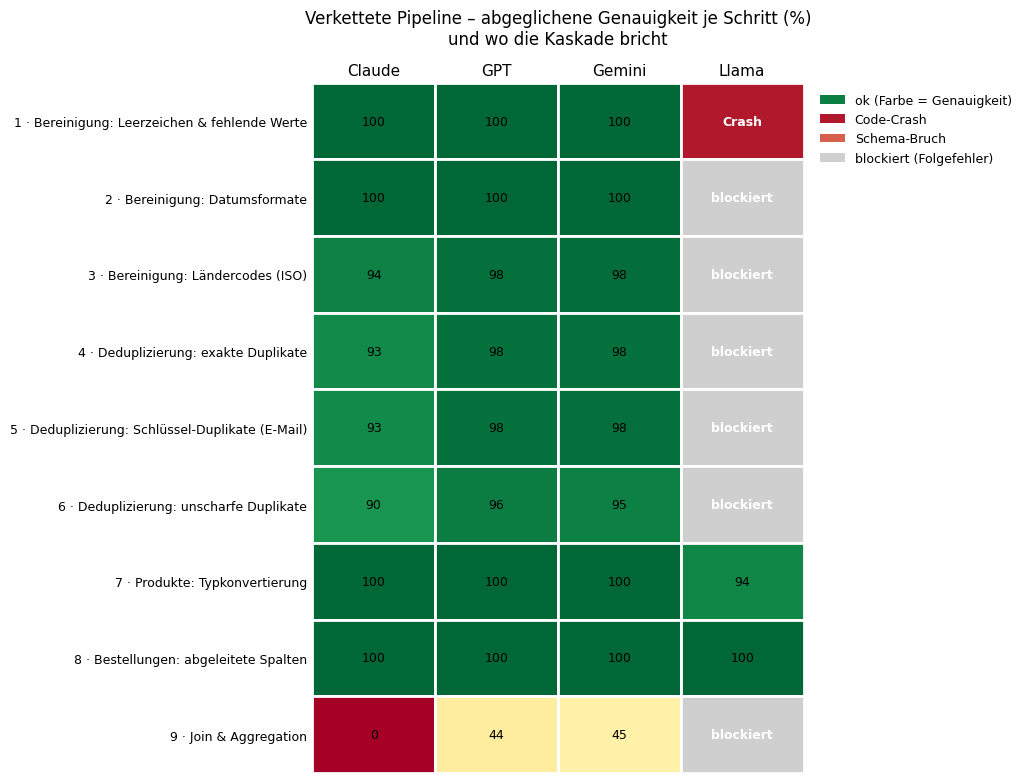

In [2]:
fig, _ = pa.pipeline_heatmap(seed); plt.show()

## 2 · Zusammenfassung je Modell

Wie weit kommt jedes Modell, wo bricht die Kette, und mit welcher Endgenauigkeit
schließt der letzte Schritt ab?

,Schritte ok,Ende erreicht,Endgenauigkeit,Erster Abbruch
Modell,,,,
Claude,9/9,ja,0.0%,—
GPT,9/9,ja,43.9%,—
Gemini,9/9,ja,45.5%,—
Llama,2/9,nein,—,1 · Bereinigung: Leerzeichen & fehlende Werte


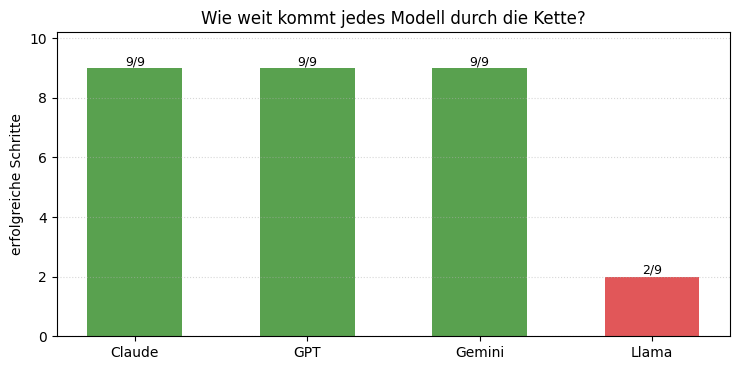

In [3]:
summary = pa.pipeline_summary(seed)
display(summary)

ok_steps = [int((pipe[pipe.provider == p].status == "ok").sum()) for p in PROVS]
fig, ax = plt.subplots(figsize=(7.5, 3.8))
bars = ax.bar(LABELS, ok_steps, 0.55,
              color=["#59a14f" if n == len(STEPS) else "#e15759" for n in ok_steps])
for r, n in zip(bars, ok_steps):
    ax.text(r.get_x() + r.get_width() / 2, n, f"{n}/{len(STEPS)}", ha="center",
            va="bottom", fontsize=9)
ax.set_ylim(0, len(STEPS) + 1.2)
ax.set_ylabel("erfolgreiche Schritte")
ax.set_title("Wie weit kommt jedes Modell durch die Kette?")
ax.grid(axis="y", ls=":", alpha=0.5)
fig.tight_layout(); compare.save_fig(fig, "pipeline_schritte_ok"); plt.show()

## 3 · Genauigkeit entlang der Schrittfolge

Der Verlauf zeigt, ob die Qualität über die Kette hinweg stabil bleibt. Ein `x` markiert
den Abbruch eines Modells, eine Lücke die dadurch blockierten Schritte
(`figures/pipeline_genauigkeit.png`).

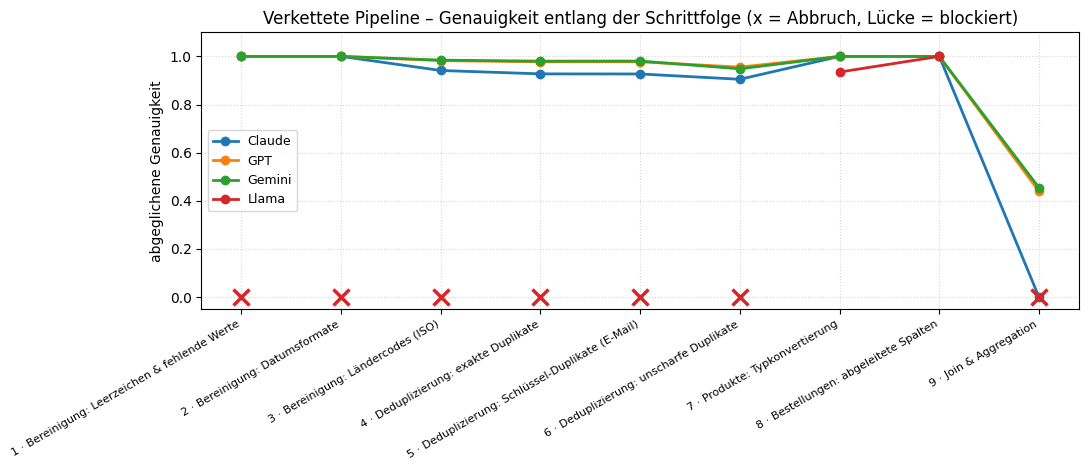

,Claude,GPT,Gemini,Llama
1 · Bereinigung: Leerzeichen & fehlende Werte,100.0,100.0,100.0,NaN
2 · Bereinigung: Datumsformate,100.0,100.0,100.0,NaN
3 · Bereinigung: Ländercodes (ISO),94.1,98.3,98.4,NaN
4 · Deduplizierung: exakte Duplikate,92.7,97.7,98.0,NaN
5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),92.7,97.8,98.1,NaN
6 · Deduplizierung: unscharfe Duplikate,90.5,95.6,94.8,NaN
7 · Produkte: Typkonvertierung,100.0,100.0,100.0,93.5
8 · Bestellungen: abgeleitete Spalten,100.0,100.0,100.0,100.0
9 · Join & Aggregation,0.0,43.9,45.5,NaN


In [4]:
fig, _ = pa.step_accuracy(seed); plt.show()

acc_tab = pipe.pivot_table(index="step", columns="provider", values="accuracy",
                           aggfunc="first").reindex(STEPS)
acc_tab = acc_tab[[p for p in PROVS if p in acc_tab.columns]]
acc_tab.index = STEP_LABELS
acc_tab.columns = [PROVIDER_LABEL[c] for c in acc_tab.columns]
status_tab = pipe.pivot_table(index="step", columns="provider", values="status",
                              aggfunc="first").reindex(STEPS)
status_tab.index = STEP_LABELS
display((acc_tab * 100).round(1))

## 4 · Aufwand: Kosten und Versuche

Die Pipeline ist deutlich günstiger als die vollständige Matrix, weil jedes Modell jeden
Schritt nur einmal (plus ggf. Retries) ausführt. Rechts wird sichtbar, wo ein Modell
Nachbesserungsversuche gebraucht hat (`figures/pipeline_aufwand.png`).

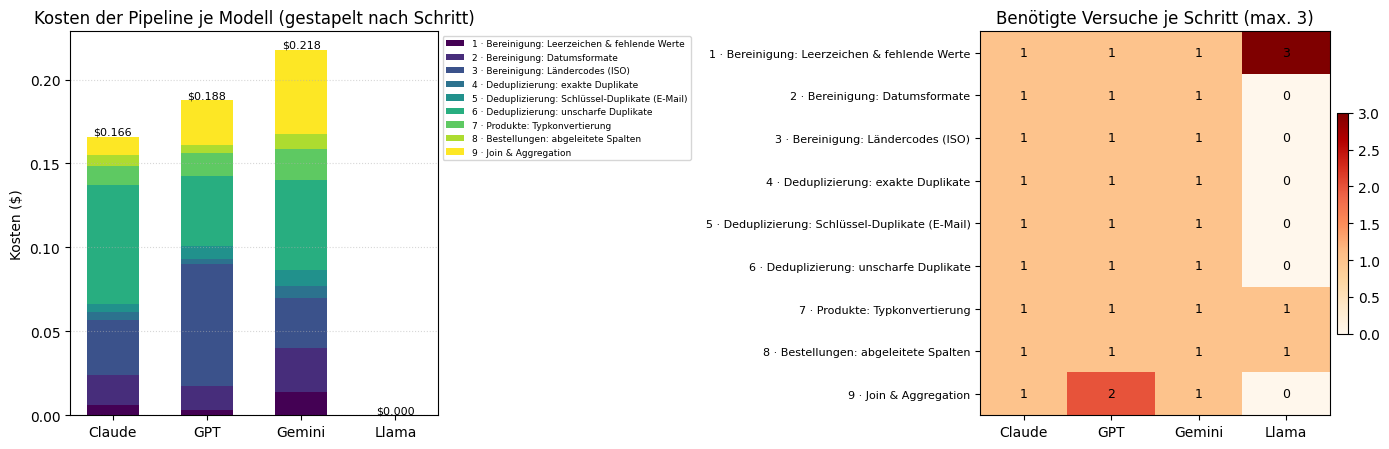

,kosten,tok_in,tok_out,versuche,schritte_ok,Kosten je ok-Schritt
Claude,0.1658,4517,10149,9,9,0.0184
GPT,0.1877,3196,11980,10,9,0.0209
Gemini,0.2178,2990,28442,9,9,0.0242
Llama,0.0000,1496,1223,5,2,0.0000


In [5]:
fig, _ = pa.effort(seed); plt.show()

kosten = (pipe.groupby("provider")
          .agg(kosten=("cost_usd", "sum"), tok_in=("prompt_tokens", "sum"),
               tok_out=("completion_tokens", "sum"), versuche=("attempts", "sum"),
               schritte_ok=("status", lambda s: int((s == "ok").sum())))
          .reindex(PROVS))
kosten.index = LABELS
kosten["Kosten je ok-Schritt"] = (kosten.kosten / kosten.schritte_ok).round(4)
kosten.round(4)

## 5 · Verkettete Pipeline gegen unabhängige Einzelläufe

Dieselbe Aufgabe einmal in der Kette (auf vorbereiteten Daten) und einmal als
unabhängiger Einzellauf auf den Rohdaten – jeweils gemittelt über die Modelle. Für den
Einzellauf wird die **beste klassische Prompt-Strategie** herangezogen, also der faire
Bestfall (`figures/pipeline_vs_einzellauf.png`).

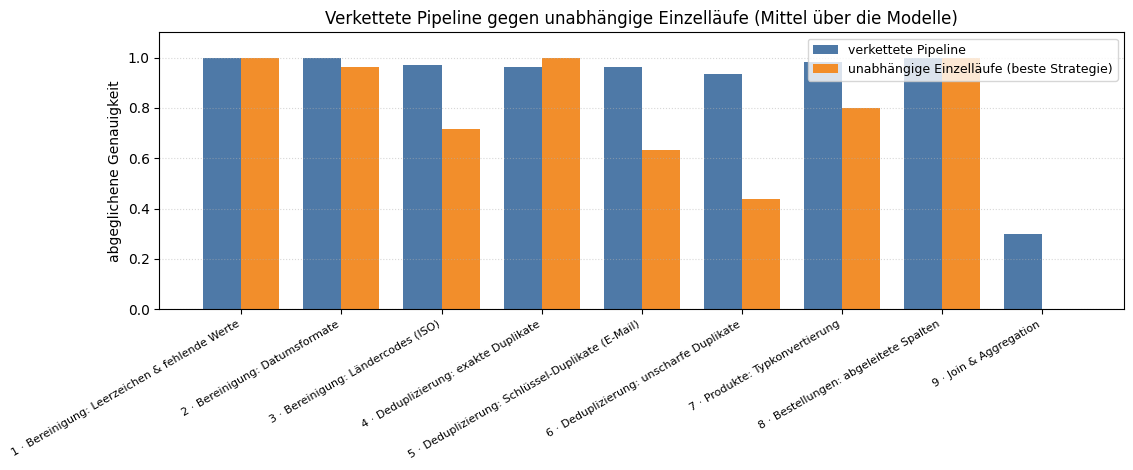

,Pipeline (Ø Modelle),"Einzellauf (beste Strategie, Ø Modelle)",Differenz
Schritt,,,
1 · Bereinigung: Leerzeichen & fehlende Werte,100.0,100.0,0.0
2 · Bereinigung: Datumsformate,100.0,96.4,3.6
3 · Bereinigung: Ländercodes (ISO),97.0,71.5,25.4
4 · Deduplizierung: exakte Duplikate,96.2,100.0,-3.8
5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),96.2,63.3,32.8
6 · Deduplizierung: unscharfe Duplikate,93.6,43.8,49.8
7 · Produkte: Typkonvertierung,98.4,80.1,18.3
8 · Bestellungen: abgeleitete Spalten,100.0,100.0,0.0
9 · Join & Aggregation,29.8,0.1,29.7


In [6]:
runs = load_runs(seed=seed, include_baseline=True)
fig, T = pa.pipeline_vs_matrix(runs, seed); plt.show()
(T * 100).round(1)

## 6 · Fehlerfortpflanzung im Endschritt

Der Endschritt (Join & Aggregation) fällt bei allen Modellen deutlich ab, obwohl Schema
und Zeilenzahl stimmen und die Gruppierungsschlüssel vollständig getroffen werden. Die
Ursache liegt **nicht** im Endschritt selbst: Weil die Deduplizierung stromaufwärts
andere Kundenzeilen entfernt als die Referenz, fallen beim Join andere Bestellungen
heraus – und jede betroffene Gruppe zählt in Umsatz *und* Bestellanzahl als falsch.

In [7]:
diag = pa.final_step_diagnosis(seed)
display(diag)

,Zeilen Ist,Zeilen Soll,Schluessel-Treffer,total_revenue_eur korrekt,order_count korrekt
Modell,,,,,
Claude,66,66,66/66,0.0,0.0
GPT,66,66,66/66,43.9,43.9
Gemini,66,66,66/66,45.5,45.5


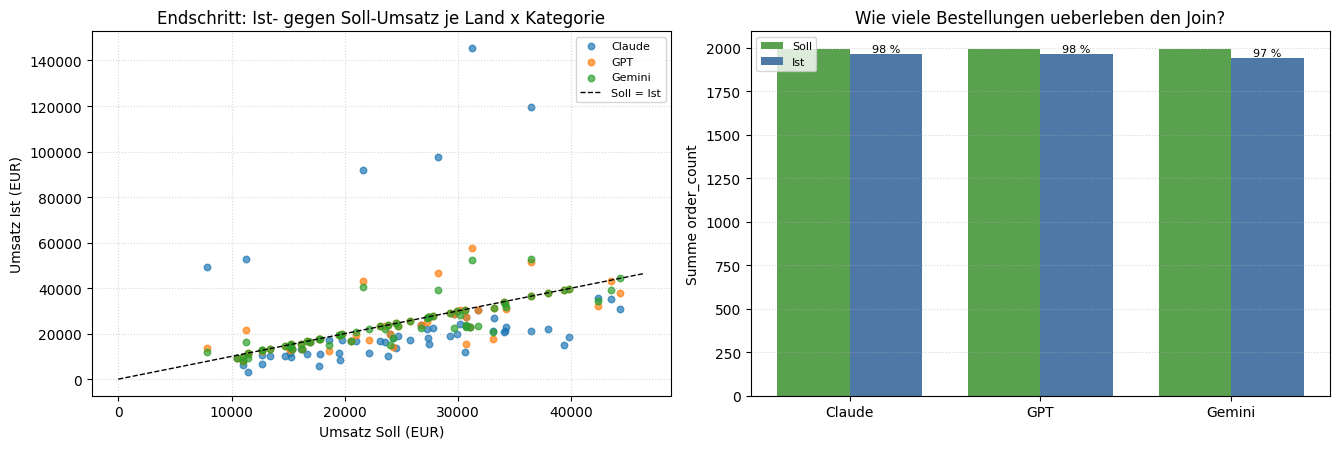

,Bestellungen Soll,Bestellungen Ist,Umsatz Soll,Umsatz Ist,Gruppen exakt %
Modell,,,,,
Claude,1995,1964,1605337.12,1582022.49,0.0
GPT,1995,1964,1605337.12,1582022.49,43.9
Gemini,1995,1941,1605337.12,1565394.81,45.5


In [8]:
from experiments.pipeline_runner import build_chain_reference
exp = build_chain_reference(seed)["final"]
keys = ["country_code", "category"]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
rows = []
for i, prov in enumerate(PROVS):
    p = pa.PIPELINE_RESULTS / str(seed) / prov / "final" / "output.parquet"
    if not p.exists():
        continue
    act = pd.read_parquet(p)[exp.columns]
    m = exp.merge(act, on=keys, suffixes=("_soll", "_ist"))
    axes[0].scatter(m.total_revenue_eur_soll, m.total_revenue_eur_ist, s=22,
                    alpha=0.7, color=f"C{i}", label=PROVIDER_LABEL[prov])
    rows.append({"Modell": PROVIDER_LABEL[prov],
                 "Bestellungen Soll": int(m.order_count_soll.sum()),
                 "Bestellungen Ist": int(m.order_count_ist.sum()),
                 "Umsatz Soll": round(float(m.total_revenue_eur_soll.sum()), 2),
                 "Umsatz Ist": round(float(m.total_revenue_eur_ist.sum()), 2),
                 "Gruppen exakt %": round(float((m.total_revenue_eur_soll
                                                 - m.total_revenue_eur_ist).abs().le(0.01).mean()) * 100, 1)})
lim = float(exp.total_revenue_eur.max()) * 1.05
axes[0].plot([0, lim], [0, lim], "k--", lw=1, label="Soll = Ist")
axes[0].set_xlabel("Umsatz Soll (EUR)")
axes[0].set_ylabel("Umsatz Ist (EUR)")
axes[0].set_title("Endschritt: Ist- gegen Soll-Umsatz je Land x Kategorie")
axes[0].legend(fontsize=8)
axes[0].grid(ls=":", alpha=0.5)

V = pd.DataFrame(rows).set_index("Modell")
x = np.arange(len(V))
axes[1].bar(x - 0.19, V["Bestellungen Soll"], 0.38, color="#59a14f", label="Soll")
axes[1].bar(x + 0.19, V["Bestellungen Ist"], 0.38, color="#4e79a7", label="Ist")
for i, (s, a) in enumerate(zip(V["Bestellungen Soll"], V["Bestellungen Ist"])):
    axes[1].text(i + 0.19, a, f"{a / s * 100:.0f} %", ha="center", va="bottom", fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(V.index)
axes[1].set_ylabel("Summe order_count")
axes[1].set_title("Wie viele Bestellungen ueberleben den Join?")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", ls=":", alpha=0.5)
fig.tight_layout(); compare.save_fig(fig, "pipeline_fehlerfortpflanzung"); plt.show()
display(V)

In [9]:
# Woher kommt die Abweichung? Zeilenzahlen der Kundentabelle entlang der Kette.
chain = build_chain_reference(seed)
rowtab = pipe[pipe.step.isin(STEPS)].pivot_table(
    index="step", columns="provider", values="row_actual", aggfunc="first").reindex(STEPS)
rowtab = rowtab[[p for p in PROVS if p in rowtab.columns]]
rowtab.columns = [PROVIDER_LABEL[c] for c in rowtab.columns]
rowtab.insert(0, "Soll", [len(chain[s]) for s in STEPS])
rowtab.index = STEP_LABELS
rowtab

,Soll,Claude,GPT,Gemini,Llama
1 · Bereinigung: Leerzeichen & fehlende Werte,540,540.0,540.0,540.0,NaN
2 · Bereinigung: Datumsformate,540,540.0,540.0,540.0,NaN
3 · Bereinigung: Ländercodes (ISO),540,540.0,540.0,540.0,NaN
4 · Deduplizierung: exakte Duplikate,520,520.0,520.0,520.0,NaN
5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),514,514.0,514.0,514.0,NaN
6 · Deduplizierung: unscharfe Duplikate,497,500.0,500.0,500.0,NaN
7 · Produkte: Typkonvertierung,100,100.0,100.0,100.0,100.0
8 · Bestellungen: abgeleitete Spalten,2000,2000.0,2000.0,2000.0,2000.0
9 · Join & Aggregation,66,66.0,66.0,66.0,NaN


## 7 · Abbrüche im Detail

Für jeden nicht erfolgreichen Schritt die protokollierte Ursache. Das lokale Modell
scheitert bereits am ersten Schritt und blockiert damit die gesamte Kundenstrecke; die
beiden von den Rohdaten gespeisten Nebenstränge (Produkte, Bestellungen) laufen trotzdem
durch.

In [10]:
fehler = pipe[pipe.status != "ok"].copy()
if len(fehler):
    fehler["Modell"] = fehler.provider.map(PROVIDER_LABEL)
    fehler["Fehler (gekuerzt)"] = fehler.error.fillna("").str.replace(r"\s+", " ", regex=True).str[:180]
    display(fehler[["Modell", "step_label", "status", "attempts", "Fehler (gekuerzt)"]]
            .reset_index(drop=True))
    for _, r in fehler[fehler.status == "code_error"].iterrows():
        print(f"\n--- {PROVIDER_LABEL[r.provider]} | {r.step_label} "
              f"(nach {r.attempts} Versuchen)\n{r.error}")
else:
    print("Kein Schritt abgebrochen.")

,Modell,step_label,status,attempts,Fehler (gekuerzt)
0,Llama,1 · Bereinigung: Leerzeichen & fehlende Werte,code_error,3,"Code-Ausführung fehlgeschlagen: le ""pandas/_li..."
1,Llama,2 · Bereinigung: Datumsformate,blocked,0,Vorheriger Schritt fehlgeschlagen
2,Llama,3 · Bereinigung: Ländercodes (ISO),blocked,0,Vorheriger Schritt fehlgeschlagen
3,Llama,4 · Deduplizierung: exakte Duplikate,blocked,0,Vorheriger Schritt fehlgeschlagen
4,Llama,5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),blocked,0,Vorheriger Schritt fehlgeschlagen
5,Llama,6 · Deduplizierung: unscharfe Duplikate,blocked,0,Vorheriger Schritt fehlgeschlagen
6,Llama,9 · Join & Aggregation,blocked,0,Vorheriger Schritt fehlgeschlagen



--- Llama | 1 · Bereinigung: Leerzeichen & fehlende Werte (nach 3 Versuchen)
Code-Ausführung fehlgeschlagen: le "pandas/_libs/tslibs/conversion.pyx", line 658, in pandas._libs.tslibs.conversion.convert_str_to_tsobject
  File "pandas/_libs/tslibs/parsing.pyx", line 321, in pandas._libs.tslibs.parsing.parse_datetime_string
  File "pandas/_libs/tslibs/parsing.pyx", line 674, in pandas._libs.tslibs.parsing.dateutil_parse
pandas._libs.tslibs.parsing.DateParseError: year 1639353600 is out of range: 1639353600



Der Beleg dafür steckt im dritten Schritt: Wer dort mehr Länder auf `UNKNOWN`
zurückfallen lässt, verschiebt die betroffenen Kunden im Endschritt in die falsche
Ländergruppe – und zwar in *jeder* Kennzahl gleichzeitig.

In [11]:
# Beleg fuer die Ursache: wie viele Kunden bekommen im 3. Schritt den falschen Laendercode?
e = chain["cleaning_hard"][["customer_id", "country"]].astype({"customer_id": str})
rows = []
for prov in PROVS:
    f = pa.PIPELINE_RESULTS / str(seed) / prov / "cleaning_hard" / "output.parquet"
    if not f.exists():
        continue
    a = pd.read_parquet(f)[["customer_id", "country"]].astype({"customer_id": str})
    m = e.merge(a, on="customer_id", suffixes=("_soll", "_ist"))
    bad = m[m.country_soll != m.country_ist]
    rows.append({"Modell": PROVIDER_LABEL[prov], "falsche Laendercodes": len(bad),
                 "davon UNKNOWN": int((bad.country_ist == "UNKNOWN").sum()),
                 "Anteil %": round(len(bad) / len(m) * 100, 1)})
pd.DataFrame(rows).set_index("Modell")

,falsche Laendercodes,davon UNKNOWN,Anteil %
Modell,,,
Claude,172,172,29.7
GPT,47,47,8.1
Gemini,44,44,7.6
Llama,523,523,90.2


## 8 · Kernaussagen des Komplettlaufs (Seed 1)

- **Drei von vier Modellen** (Claude, GPT, Gemini) durchlaufen alle neun Schritte ohne
  Abbruch; das lokale Llama scheitert **schon am ersten Schritt** (Code-Crash nach drei
  Versuchen: ein Unix-Timestamp wird als Jahreszahl geparst) und blockiert damit die
  komplette Kundenstrecke. Nur die beiden direkt von den Rohdaten gespeisten
  Nebenstränge (Produkte, Bestellungen) laufen bei ihm durch – 2 von 9 Schritten.
- **Die Kette selbst funktioniert sehr gut:** Über die ersten acht Schritte liegen
  GPT und Gemini bei 98,7 %, Claude bei 96,3 % abgeglichener Genauigkeit, und die
  Zeilenzahlen folgen der Referenz Schritt für Schritt exakt (540 → 520 → 514 → 500
  gegenüber 497 im Soll).
- **Retries sind kaum nötig:** Bis auf einen zweiten Anlauf von GPT im Endschritt
  gelingt jeder Schritt im ersten Versuch. Die Pipeline ist mit 0,17–0,22 $ je Modell
  um Größenordnungen günstiger als die vollständige Aufgaben-Matrix (6,57 $).
- **Vorbereitete Daten helfen deutlich.** Gegenüber den unabhängigen Einzelläufen auf
  Rohdaten gewinnen genau die Schritte, die auf Vorarbeit angewiesen sind: unscharfe
  Duplikate +49,8, Schlüssel-Duplikate +32,8, ISO-Ländercodes +25,4 Prozentpunkte. Die
  Schlüssel-Deduplizierung kann in der Kette nach bereits normalisiertem ISO-Datum
  sortieren – auf den Rohdaten scheitert sie an gemischten Datumsformaten.
- **Fehlerfortpflanzung ist der eigentliche Befund des Komplettlaufs.** Der Endschritt
  bricht ein, obwohl Schema, Zeilenzahl (66) und alle 66 Gruppenschlüssel stimmen: Weil
  stromaufwärts andere Kunden dedupliziert bzw. anderen Ländern zugeordnet werden,
  fallen beim Join andere Bestellungen heraus (1 964 statt 1 995) – und jede betroffene
  Gruppe ist in Umsatz **und** Bestellanzahl zugleich falsch.
- **Kleine Abweichung, große Wirkung:** Claude lässt im dritten Schritt 172 von 580
  Kunden auf `UNKNOWN` zurückfallen (GPT 47, Gemini 44). Aus 94,1 % Genauigkeit in
  Schritt 3 wird so ein Endergebnis, in dem **keine einzige** der 66 Gruppen exakt
  stimmt (0 %), während GPT und Gemini mit ihren ~98 % noch 44–46 % exakte Gruppen
  erreichen. Für die Praxis heißt das: In verketteten c{ETL}-Strecken entscheidet
  die Qualität der frühen Schritte über das Endergebnis, und eine Zwischenprüfung nach
  jedem Schritt ist wirksamer als eine Endkontrolle.